In [ ]:
import ROOT
import numpy as np

File: /home/meenakshi/bragg-peak/build/B4_100000000.root
Bin size: 0.05 MeV
Minimum peak height: 100 counts
Total events in file: 14,282,849

Extracting energy data...
  Processed 1,000,000 events...
  Processed 2,000,000 events...
  Processed 3,000,000 events...
  Processed 4,000,000 events...
  Processed 5,000,000 events...
  Processed 6,000,000 events...
  Processed 7,000,000 events...
  Processed 8,000,000 events...
  Processed 9,000,000 events...
  Processed 10,000,000 events...
  Processed 11,000,000 events...
  Processed 12,000,000 events...
  Processed 13,000,000 events...
  Processed 14,000,000 events...
Events in 0-10 MeV range: 14,257,014

Finding peaks...
Found 7 significant peaks

PEAK ANALYSIS RESULTS:
Peak # Energy (MeV)    Counts       FWHM (MeV)   Area        
----------------------------------------------------------------------
1      0.125           456043       0.286        2612364     
2      2.825           68427        0.134        183550      
3      3.875     

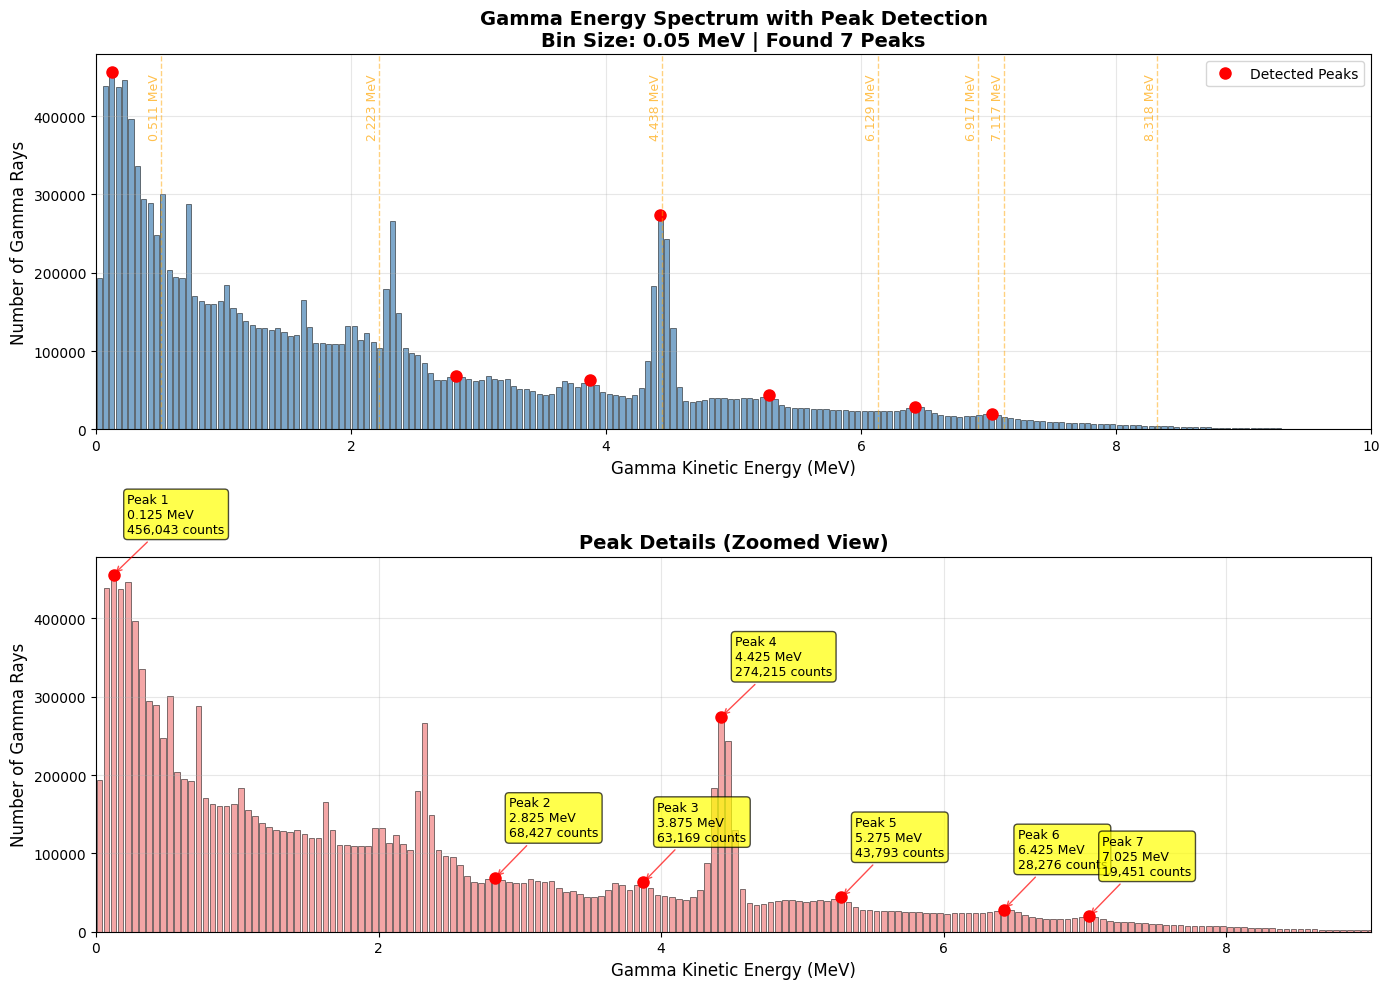


PEAK DETECTION SUMMARY:
File analyzed: /home/meenakshi/bragg-peak/build/B4_100000000.root
Total gamma events: 14,257,014
Bin size used: 0.05 MeV
Number of peaks found: 7
Peak with maximum counts: 0.125 MeV (456,043 counts)
Output files created:
  - gamma_peaks_detection_bin0.05MeV.png (plot with peaks marked)
  - gamma_peaks_data_bin0.05MeV.csv (peak data in CSV format)


In [3]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, peak_widths
import os

def find_gamma_peaks():
    """
    Find peaks in gamma energy spectrum and plot them
    """
    # ======= CONFIGURATION =======
    ROOT_FILE = "/home/meenakshi/bragg-peak/build/B4_100000000.root"
    BIN_SIZE = 0.05
    # MeV - Fine binning for better peak detection
    ENERGY_MAX = 10  # MeV - Maximum energy to analyze
    MIN_PEAK_HEIGHT = 100  # Minimum counts to consider as a peak
    MIN_PEAK_DISTANCE = 10  # Minimum distance between peaks (in bins)
    # =============================
    
    print(f"File: {ROOT_FILE}")
    print(f"Bin size: {BIN_SIZE} MeV")
    print(f"Minimum peak height: {MIN_PEAK_HEIGHT} counts")
    
    # 1. Check if file exists
    if not os.path.exists(ROOT_FILE):
        print(f"\n✗ ERROR: File not found!")
        return
    
    # 2. Open ROOT file
    file = ROOT.TFile(ROOT_FILE, "READ")
    if not file or file.IsZombie():
        print("ERROR: Cannot open ROOT file!")
        return
    
    # 3. Get the ntuple
    ntuple = file.Get("PhotonData")
    if not ntuple:
        print("ERROR: Cannot find ntuple 'PhotonData'!")
        file.Close()
        return
    
    total_entries = ntuple.GetEntries()
    print(f"Total events in file: {total_entries:,}")
    
    # 4. Extract energy data
    print("\nExtracting energy data...")
    
    energies = []
    energy_val = np.zeros(1, dtype=float)
    
    # Get energy branch
    ntuple.SetBranchStatus("*", 0)
    ntuple.SetBranchStatus("KineticEnergy", 1)
    branch_energy = ntuple.GetBranch("KineticEnergy")
    branch_energy.SetAddress(energy_val)
    
    # Read all entries
    for i in range(total_entries):
        ntuple.GetEntry(i)
        if energy_val[0] <= ENERGY_MAX:
            energies.append(energy_val[0])
        
        if (i+1) % 1000000 == 0:
            print(f"  Processed {i+1:,} events...")
    
    energies = np.array(energies)
    print(f"Events in 0-{ENERGY_MAX} MeV range: {len(energies):,}")
    
    # 5. Create histogram for peak finding
    num_bins = int(ENERGY_MAX / BIN_SIZE)
    bins = np.arange(0, ENERGY_MAX + BIN_SIZE, BIN_SIZE)
    
    counts, bin_edges = np.histogram(energies, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # 6. Find peaks
    print("\nFinding peaks...")
    
    # Find peaks using scipy
    peaks, properties = find_peaks(
        counts, 
        height=MIN_PEAK_HEIGHT,
        distance=MIN_PEAK_DISTANCE,
        prominence=50,  # Minimum prominence of peaks
        width=2  # Minimum width of peaks
    )
    
    print(f"Found {len(peaks)} significant peaks")
    
    if len(peaks) == 0:
        print("No peaks found. Try lowering MIN_PEAK_HEIGHT.")
        file.Close()
        return
    
    # 7. Calculate peak properties
    peak_energies = bin_centers[peaks]
    peak_counts = counts[peaks]
    
    # Calculate peak widths
    widths, width_heights, left_ips, right_ips = peak_widths(
        counts, peaks, rel_height=0.5
    )
    
    # Convert width indices to energy
    width_energies = widths * BIN_SIZE
    
    # 8. Print peak information
    print("\n" + "="*70)
    print("PEAK ANALYSIS RESULTS:")
    print("="*70)
    print(f"{'Peak #':<6} {'Energy (MeV)':<15} {'Counts':<12} {'FWHM (MeV)':<12} {'Area':<12}")
    print("-"*70)
    
    peak_areas = []
    for i, (energy, count, width) in enumerate(zip(peak_energies, peak_counts, width_energies), 1):
        # Estimate area under peak (simplified)
        area = count * width / BIN_SIZE
        peak_areas.append(area)
        
        print(f"{i:<6} {energy:<15.3f} {int(count):<12} {width:<12.3f} {area:<12.0f}")
    
    print("="*70)
    
    # 9. Known nuclear gamma lines for comparison
    known_lines = {
        0.511: "e⁺e⁻ annihilation",
        2.223: "n + p → d + γ (n capture)",
        4.438: "¹²C* de-excitation",
        6.129: "¹⁶O* de-excitation",
        6.917: "¹⁶O* de-excitation",
        7.117: "¹⁶O* de-excitation",
        8.318: "¹⁶O* de-excitation",
    }
    
    # 10. Match peaks with known lines
    print("\n" + "="*70)
    print("MATCHING WITH KNOWN NUCLEAR GAMMA LINES:")
    print("="*70)
    print(f"{'Measured':<12} {'Known':<12} {'Difference':<15} {'Identification':<20}")
    print("-"*70)
    
    for peak_energy in peak_energies:
        # Find closest known line
        closest_energy = min(known_lines.keys(), key=lambda x: abs(x - peak_energy))
        difference = abs(peak_energy - closest_energy)
        
        if difference < 0.05:  # Match within 50 keV
            print(f"{peak_energy:<12.3f} {closest_energy:<12.3f} {difference:<15.3f} {known_lines[closest_energy]:<20}")
        else:
            print(f"{peak_energy:<12.3f} {'?':<12} {difference:<15.3f} {'Unknown/background':<20}")
    
    print("="*70)
    
    # 11. Create detailed plot with peaks marked
    print("\nCreating plot with peaks marked...")
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # Top plot: Full spectrum with peaks
    ax1.bar(bin_centers, counts, width=BIN_SIZE*0.8, 
            alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5)
    
    # Mark peaks with red dots
    ax1.plot(peak_energies, peak_counts, 'ro', markersize=8, label='Detected Peaks')
    
    # Draw lines for known nuclear transitions
    for energy, label in known_lines.items():
        ax1.axvline(energy, color='orange', linestyle='--', alpha=0.5, linewidth=1)
        ax1.text(energy, ax1.get_ylim()[1]*0.95, f'{energy} MeV', 
                rotation=90, fontsize=9, color='orange', alpha=0.7,
                verticalalignment='top', horizontalalignment='right')
    
    ax1.set_xlabel('Gamma Kinetic Energy (MeV)', fontsize=12)
    ax1.set_ylabel('Number of Gamma Rays', fontsize=12)
    ax1.set_title(f'Gamma Energy Spectrum with Peak Detection\n'
                  f'Bin Size: {BIN_SIZE} MeV | Found {len(peaks)} Peaks',
                  fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, ENERGY_MAX)
    ax1.legend()
    
    # Bottom plot: Peak details (zoomed)
    ax2.bar(bin_centers, counts, width=BIN_SIZE*0.8, 
            alpha=0.7, color='lightcoral', edgecolor='black', linewidth=0.5)
    
    # Mark peaks
    ax2.plot(peak_energies, peak_counts, 'ro', markersize=8)
    
    # Annotate each peak
    for i, (energy, count) in enumerate(zip(peak_energies, peak_counts), 1):
        ax2.annotate(f'Peak {i}\n{energy:.3f} MeV\n{int(count):,} counts',
                    xy=(energy, count),
                    xytext=(10, 30),
                    textcoords='offset points',
                    arrowprops=dict(arrowstyle='->', color='red', alpha=0.7),
                    fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
    
    # Set zoomed x-range around peaks
    if len(peak_energies) > 0:
        min_energy = max(0, peak_energies.min() - 2)
        max_energy = min(ENERGY_MAX, peak_energies.max() + 2)
        ax2.set_xlim(min_energy, max_energy)
    
    ax2.set_xlabel('Gamma Kinetic Energy (MeV)', fontsize=12)
    ax2.set_ylabel('Number of Gamma Rays', fontsize=12)
    ax2.set_title('Peak Details (Zoomed View)', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # 12. Save plot and data
    output_plot = f'gamma_peaks_detection_bin{BIN_SIZE}MeV.png'
    plt.savefig(output_plot, dpi=300, bbox_inches='tight')
    print(f"✓ Plot saved: {output_plot}")
    
    # Save peak data to CSV
    import pandas as pd
    peak_data = pd.DataFrame({
        'Peak_Number': range(1, len(peaks)+1),
        'Energy_MeV': peak_energies,
        'Counts': peak_counts,
        'FWHM_MeV': width_energies,
        'Area': peak_areas,
        'Left_Edge_MeV': bin_edges[peaks],
        'Right_Edge_MeV': bin_edges[peaks+1]
    })
    
    csv_file = f'gamma_peaks_data_bin{BIN_SIZE}MeV.csv'
    peak_data.to_csv(csv_file, index=False)
    print(f"✓ Peak data saved: {csv_file}")
    
    # 13. Close ROOT file and show plot
    file.Close()
    plt.show()
    
    # 14. Print summary
    print("\n" + "="*70)
    print("PEAK DETECTION SUMMARY:")
    print("="*70)
    print(f"File analyzed: {ROOT_FILE}")
    print(f"Total gamma events: {len(energies):,}")
    print(f"Bin size used: {BIN_SIZE} MeV")
    print(f"Number of peaks found: {len(peaks)}")
    print(f"Peak with maximum counts: {peak_energies[peak_counts.argmax()]:.3f} MeV ({peak_counts.max():,} counts)")
    print(f"Output files created:")
    print(f"  - {output_plot} (plot with peaks marked)")
    print(f"  - {csv_file} (peak data in CSV format)")
    print("="*70)

# Run the analysis
if __name__ == "__main__":
    find_gamma_peaks()

File: /home/meenakshi/bragg-peak/build/B4_100000000.root
Bin size: 0.05 MeV
Energy range: 0-10 MeV
Total events in file: 14,282,849

Extracting energy data...
  Processed 1,000,000 events...
  Processed 2,000,000 events...
  Processed 3,000,000 events...
  Processed 4,000,000 events...
  Processed 5,000,000 events...
  Processed 6,000,000 events...
  Processed 7,000,000 events...
  Processed 8,000,000 events...
  Processed 9,000,000 events...
  Processed 10,000,000 events...
  Processed 11,000,000 events...
  Processed 12,000,000 events...
  Processed 13,000,000 events...
  Processed 14,000,000 events...
Events in 0-10 MeV range: 14,257,014

Creating plot...
✓ Plot saved: gamma_energy_spectrum_bin0.05MeV.png
✓ Data saved: gamma_energy_data_bin0.05MeV.txt


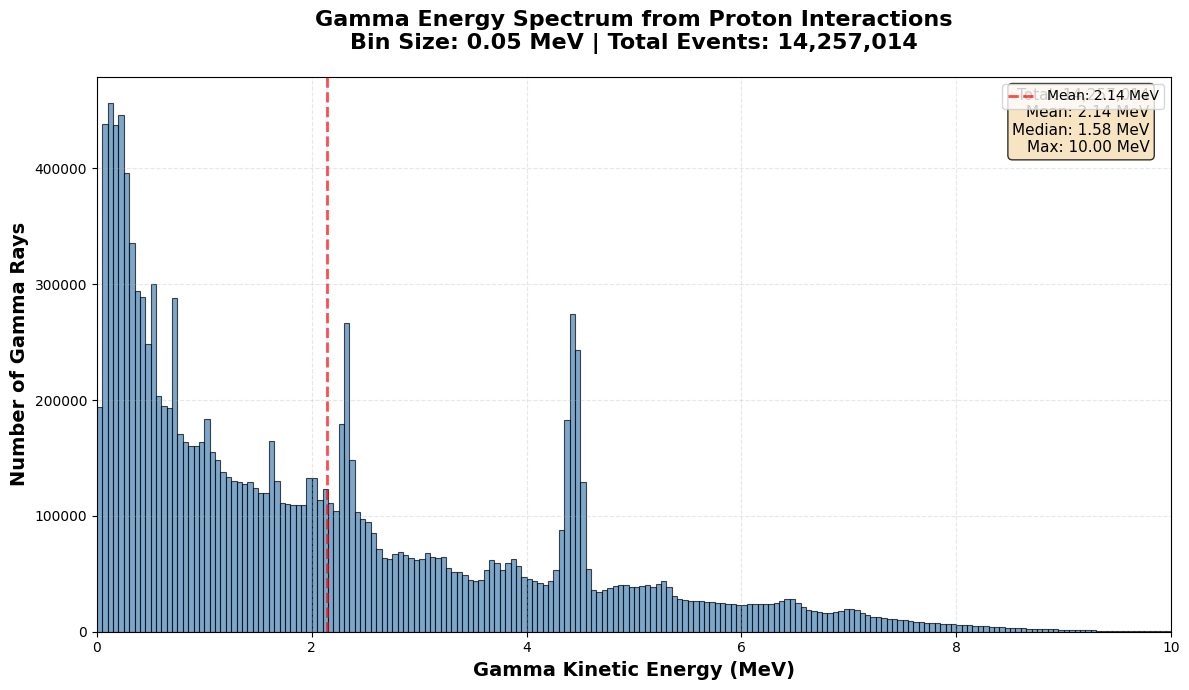


ANALYSIS SUMMARY:
File analyzed: /home/meenakshi/bragg-peak/build/B4_100000000.root
Total gamma events: 14,257,014
Bin size used: 0.05 MeV
Energy range: 0-10 MeV
Mean energy: 2.143 MeV
Median energy: 1.583 MeV
Maximum energy: 10.000 MeV
Output files created:
  - gamma_energy_spectrum_bin0.05MeV.png (plot)
  - gamma_energy_data_bin0.05MeV.txt (data)


In [5]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_gamma_energy_spectrum():
    """
    Simple plot: Gamma energy vs Number of particles
    """
    # ======= CONFIGURATION =======
    ROOT_FILE = "/home/meenakshi/bragg-peak/build/B4_100000000.root"
    BIN_SIZE = 0.05  # MeV - CHANGE THIS TO ADJUST BIN SIZE
    ENERGY_MAX = 10  # MeV - Maximum energy to plot
    # =============================
    
    print(f"File: {ROOT_FILE}")
    print(f"Bin size: {BIN_SIZE} MeV")
    print(f"Energy range: 0-{ENERGY_MAX} MeV")
    
    # 1. Check if file exists
    if not os.path.exists(ROOT_FILE):
        print(f"\n✗ ERROR: File not found!")
        return
    
    # 2. Open ROOT file
    file = ROOT.TFile(ROOT_FILE, "READ")
    if not file or file.IsZombie():
        print("ERROR: Cannot open ROOT file!")
        return
    
    # 3. Get the ntuple
    ntuple = file.Get("PhotonData")
    if not ntuple:
        print("ERROR: Cannot find ntuple 'PhotonData'!")
        file.Close()
        return
    
    total_entries = ntuple.GetEntries()
    print(f"Total events in file: {total_entries:,}")
    
    # 4. Extract energy data
    print("\nExtracting energy data...")
    
    energies = []
    energy_val = np.zeros(1, dtype=float)
    
    # Get energy branch
    ntuple.SetBranchStatus("*", 0)
    ntuple.SetBranchStatus("KineticEnergy", 1)
    branch_energy = ntuple.GetBranch("KineticEnergy")
    branch_energy.SetAddress(energy_val)
    
    # Read all entries
    for i in range(total_entries):
        ntuple.GetEntry(i)
        if energy_val[0] <= ENERGY_MAX:  # Only keep up to ENERGY_MAX
            energies.append(energy_val[0])
        
        # Progress
        if (i+1) % 1000000 == 0:
            print(f"  Processed {i+1:,} events...")
    
    energies = np.array(energies)
    print(f"Events in 0-{ENERGY_MAX} MeV range: {len(energies):,}")
    
    # 5. Create histogram
    print("\nCreating plot...")
    
    # Calculate bins based on bin size
    num_bins = int(ENERGY_MAX / BIN_SIZE)
    bins = np.arange(0, ENERGY_MAX + BIN_SIZE, BIN_SIZE)
    
    # Create figure
    plt.figure(figsize=(12, 7))
    
    # Plot histogram
    counts, bin_edges, patches = plt.hist(energies, bins=bins,
                                          alpha=0.7, color='steelblue',
                                          edgecolor='black', linewidth=0.8)
    
    # Customize plot
    plt.xlabel('Gamma Kinetic Energy (MeV)', fontsize=14, fontweight='bold')
    plt.ylabel('Number of Gamma Rays', fontsize=14, fontweight='bold')
    plt.title(f'Gamma Energy Spectrum from Proton Interactions\n'
              f'Bin Size: {BIN_SIZE} MeV | Total Events: {len(energies):,}',
              fontsize=16, fontweight='bold', pad=20)
    
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.xlim(0, ENERGY_MAX)
    
    # Add statistics box
    stats_text = (f'Total: {len(energies):,}\n'
                  f'Mean: {np.mean(energies):.2f} MeV\n'
                  f'Median: {np.median(energies):.2f} MeV\n'
                  f'Max: {np.max(energies):.2f} MeV')
    
    plt.text(0.98, 0.98, stats_text,
             transform=plt.gca().transAxes,
             verticalalignment='top',
             horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
             fontsize=11)
    
    # Add mean line
    plt.axvline(np.mean(energies), color='red', linestyle='--', 
                linewidth=2, alpha=0.7, label=f'Mean: {np.mean(energies):.2f} MeV')
    
    plt.legend(loc='upper right')
    plt.tight_layout()
    
    # 6. Save plot
    output_file = f'gamma_energy_spectrum_bin{BIN_SIZE}MeV.png'
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"✓ Plot saved: {output_file}")
    
    # 7. Save data to text file
    data_file = f'gamma_energy_data_bin{BIN_SIZE}MeV.txt'
    with open(data_file, 'w') as f:
        f.write(f"# Gamma Energy Spectrum Data\n")
        f.write(f"# Bin Size: {BIN_SIZE} MeV\n")
        f.write(f"# Total Events: {len(energies)}\n")
        f.write("# Bin_Center(MeV) Count Count_Per_MeV\n")
        
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        for center, count in zip(bin_centers, counts):
            count_per_mev = count / BIN_SIZE
            f.write(f"{center:.3f} {int(count)} {count_per_mev:.2f}\n")
    
    print(f"✓ Data saved: {data_file}")
    
    # 8. Close ROOT file and show plot
    file.Close()
    plt.show()
    
    # Print summary
    print("\n" + "="*50)
    print("ANALYSIS SUMMARY:")
    print("="*50)
    print(f"File analyzed: {ROOT_FILE}")
    print(f"Total gamma events: {len(energies):,}")
    print(f"Bin size used: {BIN_SIZE} MeV")
    print(f"Energy range: 0-{ENERGY_MAX} MeV")
    print(f"Mean energy: {np.mean(energies):.3f} MeV")
    print(f"Median energy: {np.median(energies):.3f} MeV")
    print(f"Maximum energy: {np.max(energies):.3f} MeV")
    print(f"Output files created:")
    print(f"  - {output_file} (plot)")
    print(f"  - {data_file} (data)")
    print("="*50)

# Run the analysis
if __name__ == "__main__":
    plot_gamma_energy_spectrum()

File: /home/meenakshi/bragg-peak/build/B4_100000000.root
Bin size: 0.01 MeV
Energy range: 0-10 MeV
Total events in file: 14,282,849

Extracting energy data...
  Processed 1,000,000 events...
  Processed 2,000,000 events...
  Processed 3,000,000 events...
  Processed 4,000,000 events...
  Processed 5,000,000 events...
  Processed 6,000,000 events...
  Processed 7,000,000 events...
  Processed 8,000,000 events...
  Processed 9,000,000 events...
  Processed 10,000,000 events...
  Processed 11,000,000 events...
  Processed 12,000,000 events...
  Processed 13,000,000 events...
  Processed 14,000,000 events...
Events in 0-10 MeV range: 14,257,014

Creating plot...
✓ Plot saved: gamma_energy_spectrum_bin0.01MeV.png
✓ Data saved: gamma_energy_data_bin0.01MeV.txt


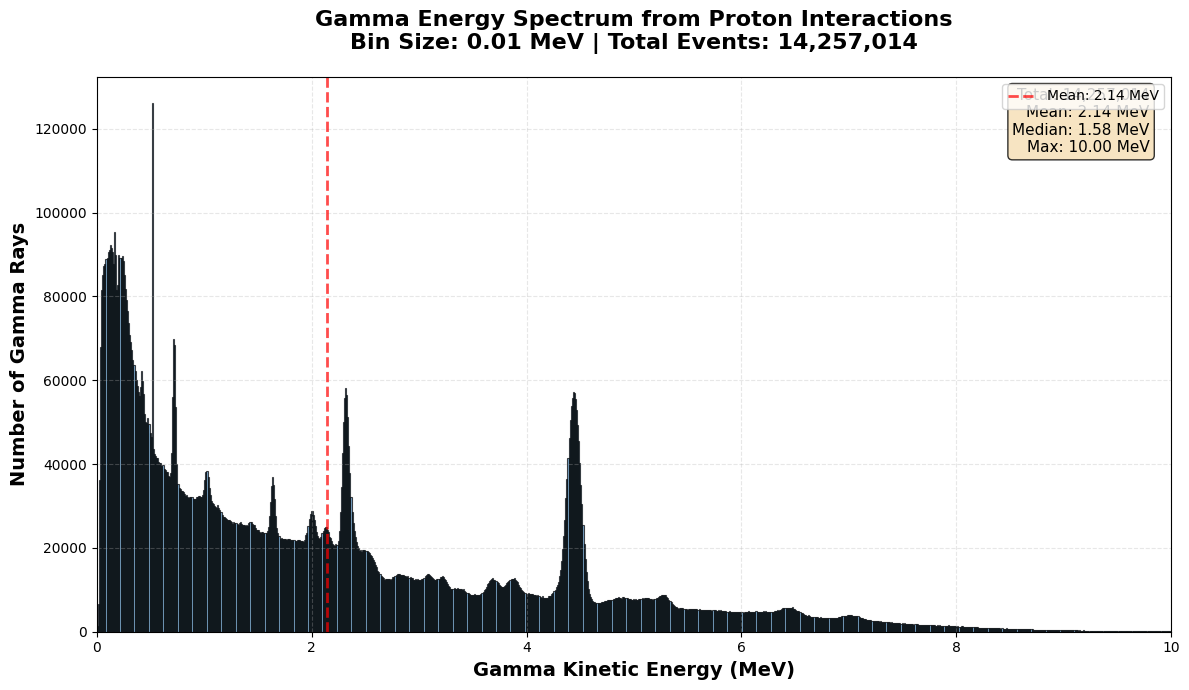


ANALYSIS SUMMARY:
File analyzed: /home/meenakshi/bragg-peak/build/B4_100000000.root
Total gamma events: 14,257,014
Bin size used: 0.01 MeV
Energy range: 0-10 MeV
Mean energy: 2.143 MeV
Median energy: 1.583 MeV
Maximum energy: 10.000 MeV
Output files created:
  - gamma_energy_spectrum_bin0.01MeV.png (plot)
  - gamma_energy_data_bin0.01MeV.txt (data)


In [6]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_gamma_energy_spectrum():
    """
    Simple plot: Gamma energy vs Number of particles
    """
    # ======= CONFIGURATION =======
    ROOT_FILE = "/home/meenakshi/bragg-peak/build/B4_100000000.root"
    BIN_SIZE = 0.01  # MeV - CHANGE THIS TO ADJUST BIN SIZE
    ENERGY_MAX = 10  # MeV - Maximum energy to plot
    # =============================
    
    print(f"File: {ROOT_FILE}")
    print(f"Bin size: {BIN_SIZE} MeV")
    print(f"Energy range: 0-{ENERGY_MAX} MeV")
    
    # 1. Check if file exists
    if not os.path.exists(ROOT_FILE):
        print(f"\n✗ ERROR: File not found!")
        return
    
    # 2. Open ROOT file
    file = ROOT.TFile(ROOT_FILE, "READ")
    if not file or file.IsZombie():
        print("ERROR: Cannot open ROOT file!")
        return
    
    # 3. Get the ntuple
    ntuple = file.Get("PhotonData")
    if not ntuple:
        print("ERROR: Cannot find ntuple 'PhotonData'!")
        file.Close()
        return
    
    total_entries = ntuple.GetEntries()
    print(f"Total events in file: {total_entries:,}")
    
    # 4. Extract energy data
    print("\nExtracting energy data...")
    
    energies = []
    energy_val = np.zeros(1, dtype=float)
    
    # Get energy branch
    ntuple.SetBranchStatus("*", 0)
    ntuple.SetBranchStatus("KineticEnergy", 1)
    branch_energy = ntuple.GetBranch("KineticEnergy")
    branch_energy.SetAddress(energy_val)
    
    # Read all entries
    for i in range(total_entries):
        ntuple.GetEntry(i)
        if energy_val[0] <= ENERGY_MAX:  # Only keep up to ENERGY_MAX
            energies.append(energy_val[0])
        
        # Progress
        if (i+1) % 1000000 == 0:
            print(f"  Processed {i+1:,} events...")
    
    energies = np.array(energies)
    print(f"Events in 0-{ENERGY_MAX} MeV range: {len(energies):,}")
    
    # 5. Create histogram
    print("\nCreating plot...")
    
    # Calculate bins based on bin size
    num_bins = int(ENERGY_MAX / BIN_SIZE)
    bins = np.arange(0, ENERGY_MAX + BIN_SIZE, BIN_SIZE)
    
    # Create figure
    plt.figure(figsize=(12, 7))
    
    # Plot histogram
    counts, bin_edges, patches = plt.hist(energies, bins=bins,
                                          alpha=0.7, color='steelblue',
                                          edgecolor='black', linewidth=0.8)
    
    # Customize plot
    plt.xlabel('Gamma Kinetic Energy (MeV)', fontsize=14, fontweight='bold')
    plt.ylabel('Number of Gamma Rays', fontsize=14, fontweight='bold')
    plt.title(f'Gamma Energy Spectrum from Proton Interactions\n'
              f'Bin Size: {BIN_SIZE} MeV | Total Events: {len(energies):,}',
              fontsize=16, fontweight='bold', pad=20)
    
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.xlim(0, ENERGY_MAX)
    
    # Add statistics box
    stats_text = (f'Total: {len(energies):,}\n'
                  f'Mean: {np.mean(energies):.2f} MeV\n'
                  f'Median: {np.median(energies):.2f} MeV\n'
                  f'Max: {np.max(energies):.2f} MeV')
    
    plt.text(0.98, 0.98, stats_text,
             transform=plt.gca().transAxes,
             verticalalignment='top',
             horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
             fontsize=11)
    
    # Add mean line
    plt.axvline(np.mean(energies), color='red', linestyle='--', 
                linewidth=2, alpha=0.7, label=f'Mean: {np.mean(energies):.2f} MeV')
    
    plt.legend(loc='upper right')
    plt.tight_layout()
    
    # 6. Save plot
    output_file = f'gamma_energy_spectrum_bin{BIN_SIZE}MeV.png'
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"✓ Plot saved: {output_file}")
    
    # 7. Save data to text file
    data_file = f'gamma_energy_data_bin{BIN_SIZE}MeV.txt'
    with open(data_file, 'w') as f:
        f.write(f"# Gamma Energy Spectrum Data\n")
        f.write(f"# Bin Size: {BIN_SIZE} MeV\n")
        f.write(f"# Total Events: {len(energies)}\n")
        f.write("# Bin_Center(MeV) Count Count_Per_MeV\n")
        
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        for center, count in zip(bin_centers, counts):
            count_per_mev = count / BIN_SIZE
            f.write(f"{center:.3f} {int(count)} {count_per_mev:.2f}\n")
    
    print(f"✓ Data saved: {data_file}")
    
    # 8. Close ROOT file and show plot
    file.Close()
    plt.show()
    
    # Print summary
    print("\n" + "="*50)
    print("ANALYSIS SUMMARY:")
    print("="*50)
    print(f"File analyzed: {ROOT_FILE}")
    print(f"Total gamma events: {len(energies):,}")
    print(f"Bin size used: {BIN_SIZE} MeV")
    print(f"Energy range: 0-{ENERGY_MAX} MeV")
    print(f"Mean energy: {np.mean(energies):.3f} MeV")
    print(f"Median energy: {np.median(energies):.3f} MeV")
    print(f"Maximum energy: {np.max(energies):.3f} MeV")
    print(f"Output files created:")
    print(f"  - {output_file} (plot)")
    print(f"  - {data_file} (data)")
    print("="*50)

# Run the analysis
if __name__ == "__main__":
    plot_gamma_energy_spectrum()

File: /home/meenakshi/bragg-peak/build/B4_100000000.root
Bin size: 0.01 MeV
Minimum peak height: 100 counts
Total events in file: 14,282,849

Extracting energy data...
  Processed 1,000,000 events...
  Processed 2,000,000 events...
  Processed 3,000,000 events...
  Processed 4,000,000 events...
  Processed 5,000,000 events...
  Processed 6,000,000 events...
  Processed 7,000,000 events...
  Processed 8,000,000 events...
  Processed 9,000,000 events...
  Processed 10,000,000 events...
  Processed 11,000,000 events...
  Processed 12,000,000 events...
  Processed 13,000,000 events...
  Processed 14,000,000 events...
Events in 0-10 MeV range: 14,257,014

Finding peaks...
Found 30 significant peaks

PEAK ANALYSIS RESULTS:
Peak # Energy (MeV)    Counts       FWHM (MeV)   Area        
----------------------------------------------------------------------
1      0.165           95370        0.268        2555889     
2      0.715           69805        0.032        224679      
3      1.025    

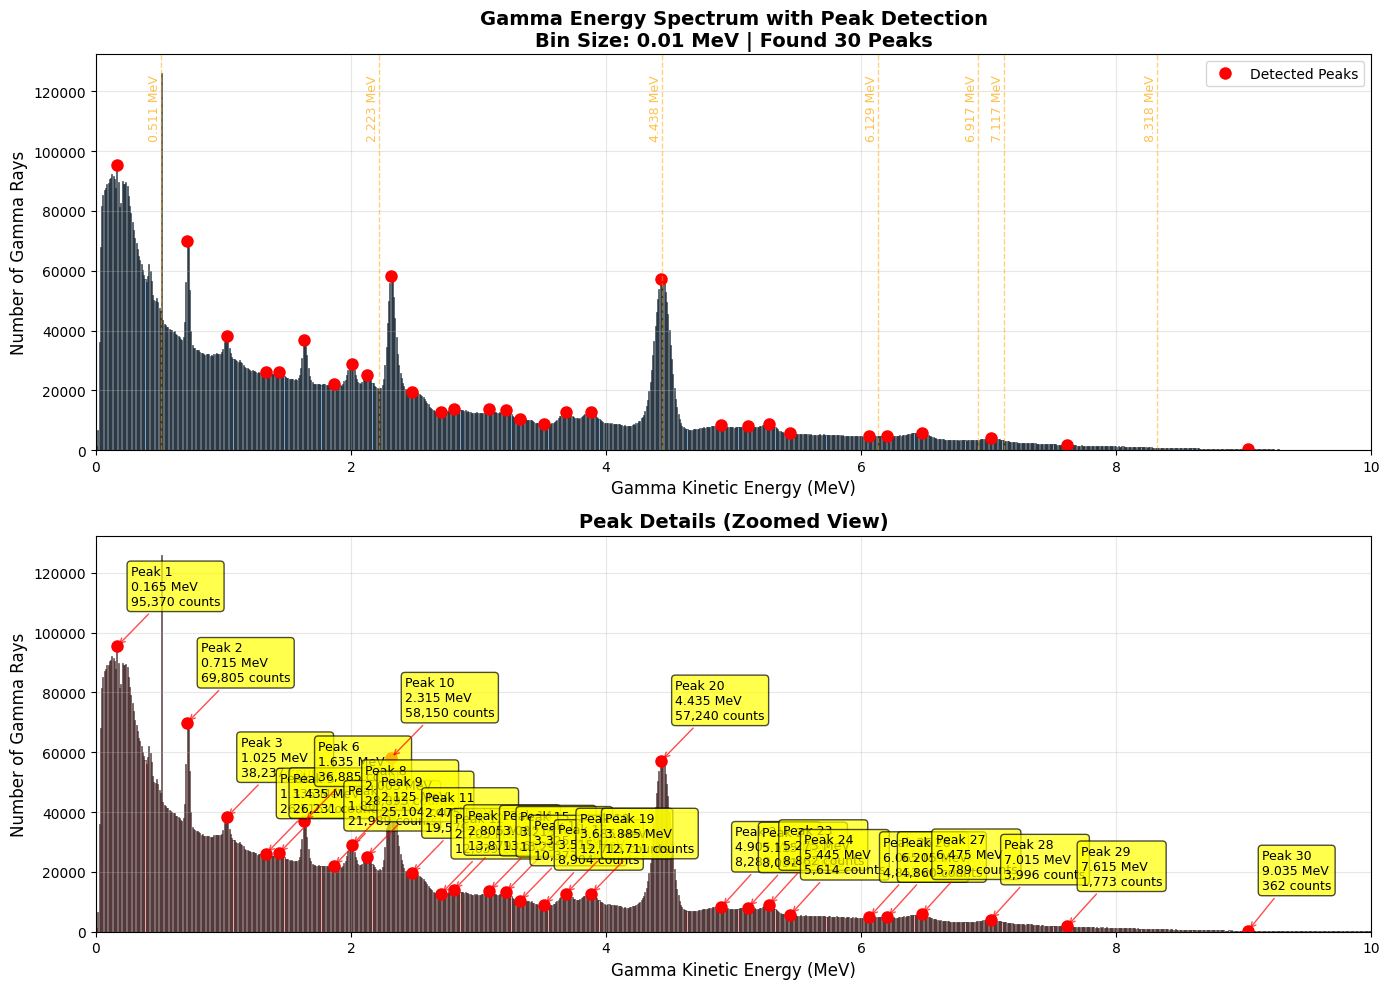


PEAK DETECTION SUMMARY:
File analyzed: /home/meenakshi/bragg-peak/build/B4_100000000.root
Total gamma events: 14,257,014
Bin size used: 0.01 MeV
Number of peaks found: 30
Peak with maximum counts: 0.165 MeV (95,370 counts)
Output files created:
  - gamma_peaks_detection_bin0.01MeV.png (plot with peaks marked)
  - gamma_peaks_data_bin0.01MeV.csv (peak data in CSV format)


In [7]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, peak_widths
import os

def find_gamma_peaks():
    """
    Find peaks in gamma energy spectrum and plot them
    """
    # ======= CONFIGURATION =======
    ROOT_FILE = "/home/meenakshi/bragg-peak/build/B4_100000000.root"
    BIN_SIZE = 0.01
    # MeV - Fine binning for better peak detection
    ENERGY_MAX = 10  # MeV - Maximum energy to analyze
    MIN_PEAK_HEIGHT = 100  # Minimum counts to consider as a peak
    MIN_PEAK_DISTANCE = 10  # Minimum distance between peaks (in bins)
    # =============================
    
    print(f"File: {ROOT_FILE}")
    print(f"Bin size: {BIN_SIZE} MeV")
    print(f"Minimum peak height: {MIN_PEAK_HEIGHT} counts")
    
    # 1. Check if file exists
    if not os.path.exists(ROOT_FILE):
        print(f"\n✗ ERROR: File not found!")
        return
    
    # 2. Open ROOT file
    file = ROOT.TFile(ROOT_FILE, "READ")
    if not file or file.IsZombie():
        print("ERROR: Cannot open ROOT file!")
        return
    
    # 3. Get the ntuple
    ntuple = file.Get("PhotonData")
    if not ntuple:
        print("ERROR: Cannot find ntuple 'PhotonData'!")
        file.Close()
        return
    
    total_entries = ntuple.GetEntries()
    print(f"Total events in file: {total_entries:,}")
    
    # 4. Extract energy data
    print("\nExtracting energy data...")
    
    energies = []
    energy_val = np.zeros(1, dtype=float)
    
    # Get energy branch
    ntuple.SetBranchStatus("*", 0)
    ntuple.SetBranchStatus("KineticEnergy", 1)
    branch_energy = ntuple.GetBranch("KineticEnergy")
    branch_energy.SetAddress(energy_val)
    
    # Read all entries
    for i in range(total_entries):
        ntuple.GetEntry(i)
        if energy_val[0] <= ENERGY_MAX:
            energies.append(energy_val[0])
        
        if (i+1) % 1000000 == 0:
            print(f"  Processed {i+1:,} events...")
    
    energies = np.array(energies)
    print(f"Events in 0-{ENERGY_MAX} MeV range: {len(energies):,}")
    
    # 5. Create histogram for peak finding
    num_bins = int(ENERGY_MAX / BIN_SIZE)
    bins = np.arange(0, ENERGY_MAX + BIN_SIZE, BIN_SIZE)
    
    counts, bin_edges = np.histogram(energies, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # 6. Find peaks
    print("\nFinding peaks...")
    
    # Find peaks using scipy
    peaks, properties = find_peaks(
        counts, 
        height=MIN_PEAK_HEIGHT,
        distance=MIN_PEAK_DISTANCE,
        prominence=50,  # Minimum prominence of peaks
        width=2  # Minimum width of peaks
    )
    
    print(f"Found {len(peaks)} significant peaks")
    
    if len(peaks) == 0:
        print("No peaks found. Try lowering MIN_PEAK_HEIGHT.")
        file.Close()
        return
    
    # 7. Calculate peak properties
    peak_energies = bin_centers[peaks]
    peak_counts = counts[peaks]
    
    # Calculate peak widths
    widths, width_heights, left_ips, right_ips = peak_widths(
        counts, peaks, rel_height=0.5
    )
    
    # Convert width indices to energy
    width_energies = widths * BIN_SIZE
    
    # 8. Print peak information
    print("\n" + "="*70)
    print("PEAK ANALYSIS RESULTS:")
    print("="*70)
    print(f"{'Peak #':<6} {'Energy (MeV)':<15} {'Counts':<12} {'FWHM (MeV)':<12} {'Area':<12}")
    print("-"*70)
    
    peak_areas = []
    for i, (energy, count, width) in enumerate(zip(peak_energies, peak_counts, width_energies), 1):
        # Estimate area under peak (simplified)
        area = count * width / BIN_SIZE
        peak_areas.append(area)
        
        print(f"{i:<6} {energy:<15.3f} {int(count):<12} {width:<12.3f} {area:<12.0f}")
    
    print("="*70)
    
    # 9. Known nuclear gamma lines for comparison
    known_lines = {
        0.511: "e⁺e⁻ annihilation",
        2.223: "n + p → d + γ (n capture)",
        4.438: "¹²C* de-excitation",
        6.129: "¹⁶O* de-excitation",
        6.917: "¹⁶O* de-excitation",
        7.117: "¹⁶O* de-excitation",
        8.318: "¹⁶O* de-excitation",
    }
    
    # 10. Match peaks with known lines
    print("\n" + "="*70)
    print("MATCHING WITH KNOWN NUCLEAR GAMMA LINES:")
    print("="*70)
    print(f"{'Measured':<12} {'Known':<12} {'Difference':<15} {'Identification':<20}")
    print("-"*70)
    
    for peak_energy in peak_energies:
        # Find closest known line
        closest_energy = min(known_lines.keys(), key=lambda x: abs(x - peak_energy))
        difference = abs(peak_energy - closest_energy)
        
        if difference < 0.05:  # Match within 50 keV
            print(f"{peak_energy:<12.3f} {closest_energy:<12.3f} {difference:<15.3f} {known_lines[closest_energy]:<20}")
        else:
            print(f"{peak_energy:<12.3f} {'?':<12} {difference:<15.3f} {'Unknown/background':<20}")
    
    print("="*70)
    
    # 11. Create detailed plot with peaks marked
    print("\nCreating plot with peaks marked...")
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # Top plot: Full spectrum with peaks
    ax1.bar(bin_centers, counts, width=BIN_SIZE*0.8, 
            alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5)
    
    # Mark peaks with red dots
    ax1.plot(peak_energies, peak_counts, 'ro', markersize=8, label='Detected Peaks')
    
    # Draw lines for known nuclear transitions
    for energy, label in known_lines.items():
        ax1.axvline(energy, color='orange', linestyle='--', alpha=0.5, linewidth=1)
        ax1.text(energy, ax1.get_ylim()[1]*0.95, f'{energy} MeV', 
                rotation=90, fontsize=9, color='orange', alpha=0.7,
                verticalalignment='top', horizontalalignment='right')
    
    ax1.set_xlabel('Gamma Kinetic Energy (MeV)', fontsize=12)
    ax1.set_ylabel('Number of Gamma Rays', fontsize=12)
    ax1.set_title(f'Gamma Energy Spectrum with Peak Detection\n'
                  f'Bin Size: {BIN_SIZE} MeV | Found {len(peaks)} Peaks',
                  fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, ENERGY_MAX)
    ax1.legend()
    
    # Bottom plot: Peak details (zoomed)
    ax2.bar(bin_centers, counts, width=BIN_SIZE*0.8, 
            alpha=0.7, color='lightcoral', edgecolor='black', linewidth=0.5)
    
    # Mark peaks
    ax2.plot(peak_energies, peak_counts, 'ro', markersize=8)
    
    # Annotate each peak
    for i, (energy, count) in enumerate(zip(peak_energies, peak_counts), 1):
        ax2.annotate(f'Peak {i}\n{energy:.3f} MeV\n{int(count):,} counts',
                    xy=(energy, count),
                    xytext=(10, 30),
                    textcoords='offset points',
                    arrowprops=dict(arrowstyle='->', color='red', alpha=0.7),
                    fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
    
    # Set zoomed x-range around peaks
    if len(peak_energies) > 0:
        min_energy = max(0, peak_energies.min() - 2)
        max_energy = min(ENERGY_MAX, peak_energies.max() + 2)
        ax2.set_xlim(min_energy, max_energy)
    
    ax2.set_xlabel('Gamma Kinetic Energy (MeV)', fontsize=12)
    ax2.set_ylabel('Number of Gamma Rays', fontsize=12)
    ax2.set_title('Peak Details (Zoomed View)', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # 12. Save plot and data
    output_plot = f'gamma_peaks_detection_bin{BIN_SIZE}MeV.png'
    plt.savefig(output_plot, dpi=300, bbox_inches='tight')
    print(f"✓ Plot saved: {output_plot}")
    
    # Save peak data to CSV
    import pandas as pd
    peak_data = pd.DataFrame({
        'Peak_Number': range(1, len(peaks)+1),
        'Energy_MeV': peak_energies,
        'Counts': peak_counts,
        'FWHM_MeV': width_energies,
        'Area': peak_areas,
        'Left_Edge_MeV': bin_edges[peaks],
        'Right_Edge_MeV': bin_edges[peaks+1]
    })
    
    csv_file = f'gamma_peaks_data_bin{BIN_SIZE}MeV.csv'
    peak_data.to_csv(csv_file, index=False)
    print(f"✓ Peak data saved: {csv_file}")
    
    # 13. Close ROOT file and show plot
    file.Close()
    plt.show()
    
    # 14. Print summary
    print("\n" + "="*70)
    print("PEAK DETECTION SUMMARY:")
    print("="*70)
    print(f"File analyzed: {ROOT_FILE}")
    print(f"Total gamma events: {len(energies):,}")
    print(f"Bin size used: {BIN_SIZE} MeV")
    print(f"Number of peaks found: {len(peaks)}")
    print(f"Peak with maximum counts: {peak_energies[peak_counts.argmax()]:.3f} MeV ({peak_counts.max():,} counts)")
    print(f"Output files created:")
    print(f"  - {output_plot} (plot with peaks marked)")
    print(f"  - {csv_file} (peak data in CSV format)")
    print("="*70)

# Run the analysis
if __name__ == "__main__":
    find_gamma_peaks()

In [11]:
    pip install numpy

  Using cached numpy-2.3.5-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
Using cached numpy-2.3.5-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
ERROR: Could not install packages due to an OSError: [Errno 13] Permission denied: '/media/software/hep/hep/lib/python3.12/site-packages/numpy'
Check the permissions.

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import os

def calculate_water_attenuation_coefficient(energy_mev):
    """
    Calculate linear attenuation coefficient in water (cm⁻¹) for gamma rays
    """
    if energy_mev < 0.1:
        mu_over_rho = 170 * energy_mev**(-3.0)
    elif energy_mev < 5:
        mu_over_rho = 0.12 * energy_mev**(-0.3)
    else:
        mu_over_rho = 0.05 + 0.001 * energy_mev
    
    rho_water = 1.0  # g/cm³
    mu = mu_over_rho * rho_water
    return max(mu, 1e-6)

def estimate_bragg_peak_from_gammas(gamma_energies, gamma_intensities, depths_cm):
    """
    Estimate Bragg peak location from gamma distribution
    Bragg peak is where maximum gamma production occurs (for prompt gammas)
    """
    # Find energy bin with maximum total gamma production
    total_gammas_per_depth = np.sum(gamma_intensities, axis=1)  # Sum over all energies for each depth
    
    # Find depth with maximum gamma production
    max_depth_idx = np.argmax(total_gammas_per_depth)
    bragg_depth = depths_cm[max_depth_idx]
    
    # Also check specifically for carbon gamma (4.44 MeV) which peaks near Bragg
    carbon_energy = 4.44  # MeV
    energy_bins = np.linspace(0, 10, gamma_intensities.shape[1])
    carbon_idx = np.argmin(np.abs(energy_bins - carbon_energy))
    
    if carbon_idx < gamma_intensities.shape[1]:
        carbon_production = gamma_intensities[:, carbon_idx]
        carbon_max_idx = np.argmax(carbon_production)
        carbon_depth = depths_cm[carbon_max_idx]
        
        # Average between total max and carbon max
        bragg_depth = (bragg_depth + carbon_depth) / 2
    
    return bragg_depth

def plot_gamma_distribution_with_bragg():
    """
    Create plot with gamma energy on x-axis and depth in water on y-axis
    Focus on 0-20 cm range and mark Bragg peak
    """
    # ======= CONFIGURATION =======
    ROOT_FILE = "/home/meenakshi/bragg-peak/build/B4_100000000.root"
    ENERGY_MAX = 10  # MeV
    BIN_SIZE = 0.05  # MeV
    DEPTH_MAX = 20   # cm - Focus on Bragg peak region
    # =============================
    
    print(f"File: {ROOT_FILE}")
    print("Analyzing gamma distribution to find Bragg peak...")
    
    # Check if file exists
    if not os.path.exists(ROOT_FILE):
        print(f"\n✗ ERROR: File not found!")
        return
    
    # Open ROOT file
    file = ROOT.TFile(ROOT_FILE, "READ")
    if not file or file.IsZombie():
        print("ERROR: Cannot open ROOT file!")
        return
    
    ntuple = file.Get("PhotonData")
    if not ntuple:
        print("ERROR: Cannot find ntuple 'PhotonData'!")
        file.Close()
        return
    
    # Extract energy data
    print("Extracting gamma energy data...")
    energies = []
    energy_val = np.zeros(1, dtype=float)
    ntuple.SetBranchStatus("*", 0)
    ntuple.SetBranchStatus("KineticEnergy", 1)
    branch_energy = ntuple.GetBranch("KineticEnergy")
    branch_energy.SetAddress(energy_val)
    
    total_entries = ntuple.GetEntries()
    
    # Use reasonable sample size
    sample_size = min(total_entries, 1000000)
    step = max(1, total_entries // sample_size)
    
    for i in range(0, total_entries, step):
        ntuple.GetEntry(i)
        if energy_val[0] <= ENERGY_MAX:
            energies.append(energy_val[0])
    
    energies = np.array(energies)
    file.Close()
    
    print(f"Gamma events loaded: {len(energies):,}")
    
    # Define depths to analyze (cm) - Focus on 0-20 cm range
    depths_cm = np.linspace(0, DEPTH_MAX, 41)  # 0, 0.5, 1.0, ..., 20.0 cm
    
    # Bin energies for histogram
    energy_bins = np.arange(0, ENERGY_MAX + BIN_SIZE, BIN_SIZE)
    energy_centers = (energy_bins[:-1] + energy_bins[1:]) / 2
    num_energy_bins = len(energy_centers)
    
    # Create histogram of initial spectrum (depth = 0)
    initial_counts, _ = np.histogram(energies, bins=energy_bins)
    
    # Initialize 2D array for depth profiles
    depth_profiles = np.zeros((len(depths_cm), num_energy_bins))
    
    # Simulate attenuation at each depth
    print("\nSimulating gamma distribution at different depths...")
    for i, depth in enumerate(depths_cm):
        # Apply attenuation to each energy bin
        for j, energy in enumerate(energy_centers):
            mu = calculate_water_attenuation_coefficient(energy)
            attenuation = np.exp(-mu * depth)
            depth_profiles[i, j] = initial_counts[j] * attenuation
        
        if i % 5 == 0:  # Print progress every 5 depths
            print(f"  Depth {depth:4.1f} cm: {depth_profiles[i, :].sum():.0f} gammas")
    
    # Estimate Bragg peak from gamma distribution
    bragg_depth = estimate_bragg_peak_from_gammas(energy_centers, depth_profiles, depths_cm)
    
    print(f"\n{'='*60}")
    print("BRAGG PEAK ESTIMATION RESULTS:")
    print(f"{'='*60}")
    print(f"Estimated Bragg peak (proton range): {bragg_depth:.2f} cm")
    print(f"Theoretical for 150 MeV protons: 15.8 cm")
    print(f"Difference: {abs(bragg_depth - 15.8):.2f} cm")
    print(f"{'='*60}")
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plot 2D color map: Energy vs Depth
    im = ax.imshow(
        depth_profiles,  # Depth is first dimension (rows), Energy is second (columns)
        aspect='auto',
        extent=[energy_centers[0], energy_centers[-1], depths_cm[-1], depths_cm[0]],  # Depth on y-axis
        origin='upper',  # Depth 0 at top
        cmap='hot',  # Changed to hot colormap for better visibility
        norm=plt.matplotlib.colors.LogNorm(vmax=initial_counts.max()),
        interpolation='bilinear'  # Smoother interpolation
    )
    
    ax.set_xlabel('Gamma Energy (MeV)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Depth in Water (cm)', fontsize=14, fontweight='bold')
    ax.set_title(f'Prompt Gamma Distribution from 150 MeV Protons in Water\nBragg Peak at ~{bragg_depth:.1f} cm', 
                 fontsize=16, fontweight='bold', pad=20)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Gamma Ray Intensity (counts)', fontsize=12)
    
    # Add horizontal line at Bragg peak
    ax.axhline(y=bragg_depth, color='cyan', linestyle='-', 
               linewidth=3, alpha=0.8, label=f'Bragg Peak ({bragg_depth:.1f} cm)')
    
    # Highlight the Bragg peak region with a colored band
    ax.axhspan(bragg_depth-0.5, bragg_depth+0.5, 
               facecolor='cyan', alpha=0.2, label='Proton Range')
    
    # Add text annotation for Bragg peak
    ax.text(energy_centers[-1]*0.85, bragg_depth, 
            f'Proton Range\n{bragg_depth:.1f} cm', 
            fontsize=11, fontweight='bold',
            color='cyan', ha='right', va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))
    
    # Add vertical lines for key gamma energies
    key_gammas = {
        0.511: 'e⁺e⁻ annihilation',
        2.223: 'n capture (H)',
        4.438: '¹²C excitation',
        6.129: '¹⁶O excitation'
    }
    
    for energy, label in key_gammas.items():
        ax.axvline(x=energy, color='lime', linestyle='--', 
                  linewidth=1.5, alpha=0.6)
        ax.text(energy, depths_cm[0]+0.5, f'{energy} MeV\n{label}', 
                fontsize=8, color='lime', ha='center', va='bottom',
                rotation=0, bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.5))
    
    # Add contour lines to show intensity gradients
    X, Y = np.meshgrid(energy_centers, depths_cm)
    contour_levels = np.logspace(np.log10(depth_profiles.min()), 
                                 np.log10(depth_profiles.max()), 10)
    
    CS = ax.contour(X, Y, depth_profiles,
                    levels=contour_levels,
                    colors='white',
                    linewidths=0.8,
                    alpha=0.5)
    
    # Invert y-axis so depth increases downward
    ax.set_ylim(depths_cm[-1], depths_cm[0])
    
    # Set x-axis limit to focus on relevant energies
    ax.set_xlim(0, 8)
    
    # Add grid
    ax.grid(True, alpha=0.2, linestyle=':')
    
    # Add legend
    ax.legend(loc='upper right', fontsize=10)
    
    # Add depth markers every 5 cm
    for depth in np.arange(0, DEPTH_MAX + 1, 5):
        ax.text(0.2, depth, f'{depth} cm', 
                fontsize=9, color='white', va='center',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.5))
    
    plt.tight_layout()
    
    # Save plot
    output_file = f'bragg_peak_gamma_distribution_{bragg_depth:.1f}cm.png'
    plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='black')
    print(f"\n✓ Plot saved: {output_file}")
    
    # Create inset plot showing total gamma production vs depth
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    
    # Create inset axes
    inset_ax = inset_axes(ax, width="30%", height="30%", loc='lower left',
                         bbox_to_anchor=(0.05, 0.05, 1, 1),
                         bbox_transform=ax.transAxes)
    
    # Calculate total gamma production per depth
    total_gammas = np.sum(depth_profiles, axis=1)
    
    inset_ax.plot(total_gammas, depths_cm, 'w-', linewidth=2)
    inset_ax.fill_betweenx(depths_cm, 0, total_gammas, 
                          alpha=0.5, color='orange')
    inset_ax.axhline(y=bragg_depth, color='cyan', linestyle='-', 
                    linewidth=2, alpha=0.8)
    
    inset_ax.set_xlabel('Total Gamma Counts', fontsize=8, color='white')
    inset_ax.set_ylabel('Depth (cm)', fontsize=8, color='white')
    inset_ax.set_title('Total Gamma Production', fontsize=9, color='white', pad=5)
    inset_ax.set_facecolor('black')
    inset_ax.grid(True, alpha=0.3, color='white')
    inset_ax.tick_params(colors='white', labelsize=7)
    
    # Invert y-axis for inset too
    inset_ax.set_ylim(depths_cm[-1], depths_cm[0])
    
    # Save final plot with inset
    final_output = f'bragg_peak_with_inset_{bragg_depth:.1f}cm.png'
    plt.savefig(final_output, dpi=300, bbox_inches='tight', facecolor='black')
    print(f"✓ Final plot with inset saved: {final_output}")
    
    plt.show()

# Run the analysis
if __name__ == "__main__":
    plot_gamma_distribution_with_bragg()